# Dealing with 2.5D depthmaps and cameras

This notebook shows various short experiments and snippets for dealing with 2D depth map 
data and the pinhole camera model.

The main components discussed here are the tensor subclasses:

    - `unipercept.data.tensors.DepthMap`
    - `unipercept.data.tensors.PinholeCamera`

For further reading, refer to the documentation.

## Setup and configuration

The cell below selects a dataset and samples an `unipercept.model.InputData` object from 
it. Run it before any of the other cells in the notebook.

In [1]:
import typing as T
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import matplotlib.pyplot as plt
from einops import reduce, rearrange
import torch
import torchvision.transforms.v2 as tvfn
import unipercept as up

dataset = up.data.sets.catalog.get_dataset("cityscapes-vps")(split="val", all=False)
queue, pipe = dataset()
sample = T.cast(up.model.InputData, next(iter(pipe)))


## Displaying a depth map

Depthmaps may be displayed via `up.render.draw_image_depth`.

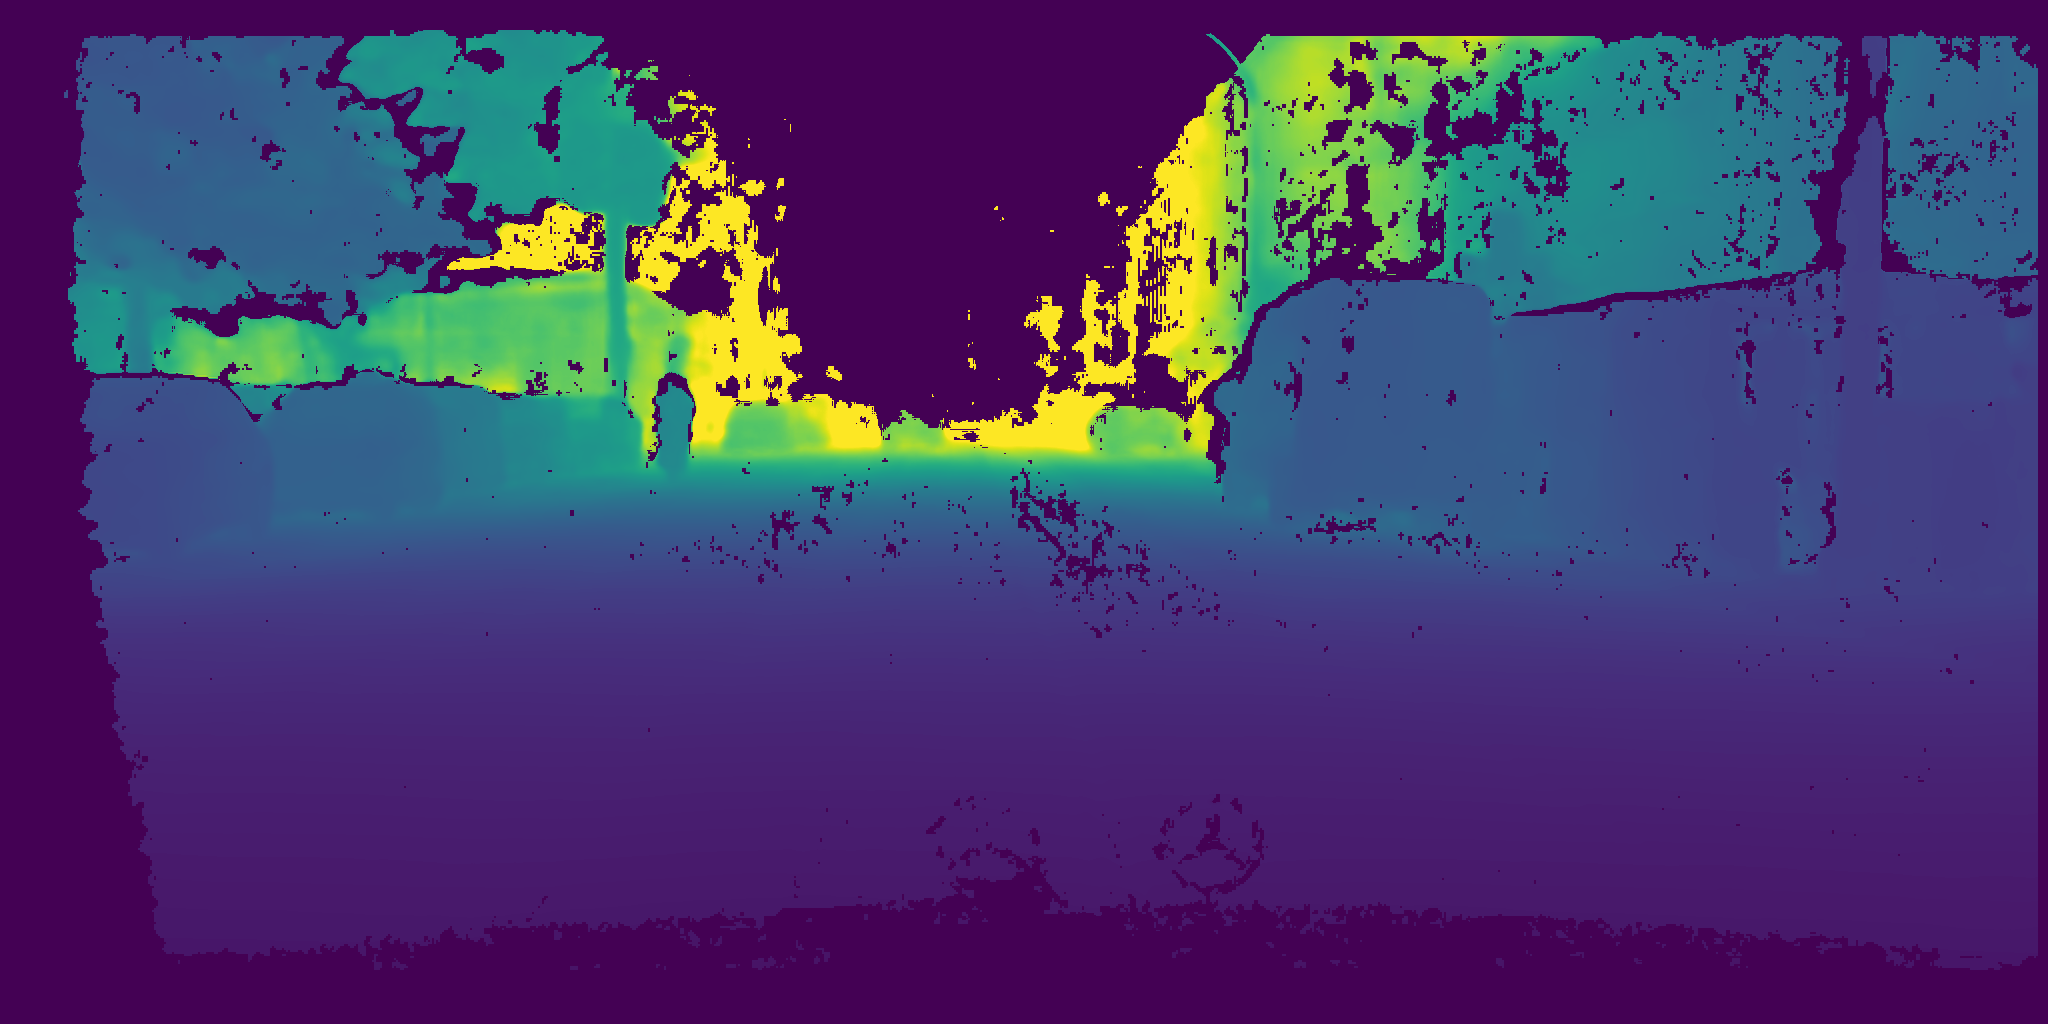

In [2]:
up.render.draw_image_depth(sample.captures.depths, info=dataset.info)


## Effects of various depth interpolation methods

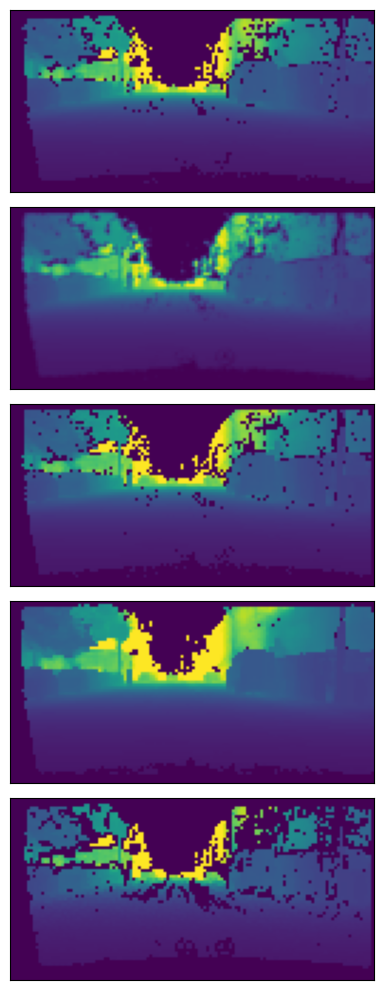

In [3]:
from torchvision.transforms.v2.functional import (
    resize_mask,
    resize_image,
    InterpolationMode,
)

dmap = sample.captures.depths


def resize_median(dmap, size):
    dmap = rearrange(
        dmap, "b (h1 h2) (w1 w2) -> b h1 w1 (h2 w2)", h1=size[0], w1=size[1]
    )
    dmap[dmap <= 0] = torch.nan
    dmap = torch.nanmedian(dmap, dim=-1).values
    dmap[~torch.isfinite(dmap)] = 0

    return dmap


def resize_mode(dmap, size):
    dmap = rearrange(
        dmap, "b (h1 h2) (w1 w2) -> b h1 w1 (h2 w2)", h1=size[0], w1=size[1]
    )
    return torch.mode(dmap, dim=-1).values


size_out = [n := 64, n * 2]


fig, axs = plt.subplots(5, 1, figsize=(20, 10))
axs_iter = iter(axs)
up.render.draw_image_depth(
    resize_mask(
        dmap,
        size_out,
    ),
    ax=next(axs_iter),
    info=dataset.info,
)
up.render.draw_image_depth(
    resize_image(
        dmap,
        size_out,
    ),
    ax=next(axs_iter),
    info=dataset.info,
)
up.render.draw_image_depth(
    resize_image(dmap, size_out, interpolation=InterpolationMode.NEAREST_EXACT),
    ax=next(axs_iter),
    info=dataset.info,
)
up.render.draw_image_depth(
    resize_median(
        dmap,
        size_out,
    ),
    ax=next(axs_iter),
    info=dataset.info,
)
up.render.draw_image_depth(
    resize_mode(
        dmap,
        size_out,
    ),
    ax=next(axs_iter),
    info=dataset.info,
)
fig.tight_layout()


## Using cameras

In [4]:
cam = sample.cameras
print(cam)

print(cam.intrinsic_matrix[..., :2, :2].diagonal(0, -2, -1))
print(cam.extrinsic_matrix)
print(cam.canvas_bbox)


PinholeCamera(torch.float32, shape=torch.Size([1, 4, 10]), device=cpu, requires_grad=False){
  focal_length: [[2268.360107421875, 2225.54052734375]]
  principal_point: [[1048.6400146484375, 519.2769775390625]]
  rotation: [[[0.9999755024909973, 0.0003498513251543045, 0.006991195026785135], [0.0, 0.9987502694129944, -0.04997916892170906], [-0.0069999429397284985, 0.04997794330120087, 0.9987258315086365]]]
  translation: [[[0.9999755024909973, 0.0003498513251543045, 0.006991195026785135], [0.0, 0.9987502694129944, -0.04997916892170906], [-0.0069999429397284985, 0.04997794330120087, 0.9987258315086365]]]
  canvas_size: [[1024.0, 2048.0]]
  canvas_center: [[512.0, 1024.0]]
}
Tensor(float32, shape=(1,2), device=cpu, requires_grad=False){[[2268.360107421875, 2225.54052734375]]}
Tensor(float32, shape=(1,4,4), device=cpu, requires_grad=False){[[[0.9999755024909973, 0.0003498513251543045, 0.006991195026785135, 1.7000000476837158], [0.0, 0.9987502694129944, -0.04997916892170906, -0.1000000014901